## Fairness in AI

Julien VELCIN, Ecole Centrale de Lyon

BachelorBSc Data Science for Responsible Business


## Example: adult income data

Download the <a href="https://archive.ics.uci.edu/dataset/2/adult">dataset from the UCI repo</a> and load it with `pandas`.

Pay attention that no header is provided.

Set the columns names to the right variable names which are:

"age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"

Take a look at your data.

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Number of rows in income: 32561 and number of columns: 15


Several variables ("sex", "race", "income") contains annoying spaces surrounding values (" White" instead of "White"). You can easily get rid of them by using the `str.strip()` function for each cell.

Draw some plots to show contingency information between:

- Gender and income
- Race and income

You can use the nice `mosaic` plot provided by the module <a href="https://www.statsmodels.org/stable/index.html">`statsmodels.graphics.mosaicplot`</a>

What are your conclusions?


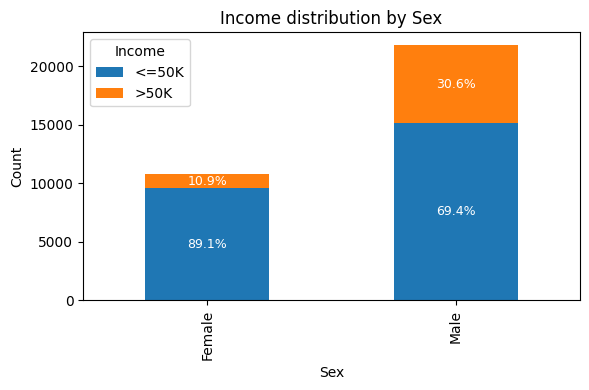

(<Figure size 640x480 with 3 Axes>,
 {('Male', '<=50K'): (0.0,
   np.float64(0.0),
   0.6658761106784497,
   np.float64(0.691956900586846)),
  ('Male', '>50K'): (0.0,
   np.float64(0.6952791597230586),
   0.6658761106784497,
   np.float64(0.3047208402769413)),
  ('Female', '<=50K'): (0.6708512350565591,
   np.float64(0.0),
   0.32914876494344103,
   np.float64(0.887580808686793)),
  ('Female', '>50K'): (0.6708512350565591,
   np.float64(0.8909030678230057),
   0.32914876494344103,
   np.float64(0.10909693217699425))})

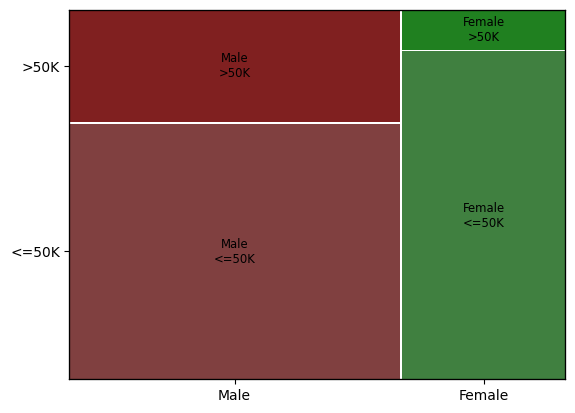

(<Figure size 640x480 with 3 Axes>,
 {('White', '<=50K'): (0.0,
   np.float64(0.0),
   0.8945575934162415,
   np.float64(0.7416678371491061)),
  ('White', '>50K'): (0.0,
   np.float64(0.7449900962853186),
   0.8945575934162415,
   np.float64(0.25500990371468124)),
  ('Black', '<=50K'): (0.899532717794351,
   np.float64(0.0),
   0.10046728220564918,
   np.float64(0.8732096596492273)),
  ('Black', '>50K'): (0.899532717794351,
   np.float64(0.8765319187854398),
   0.10046728220564918,
   np.float64(0.1234680812145601))})

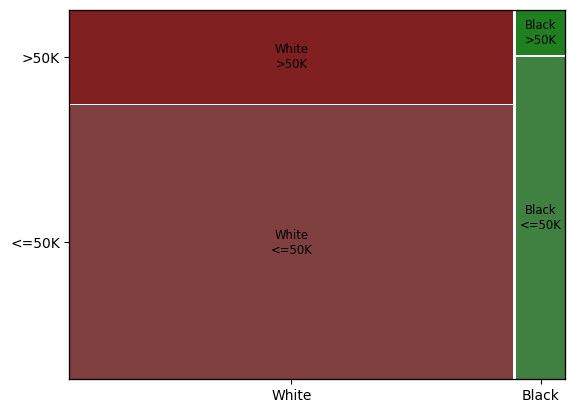

### Build machine learning algorithms

Now, we would like to build a prediction model based solely on non-protected attributes.

Using `scikit-learn`, build several simple models (decision tree, SVM...) that predicts income from the other variables. Don't forget to hide the two protected attributes.

First, copy the dataframe into a new `income_ML` dataframe and print the class distribution.

income
<=50K    24720
>50K      7841
Name: count, dtype: int64


It's usually easier to deal with integer values for the class variable.
Create a new column named `class` with 1 when income is >50K and 0 otherwise.
Drop the previous `income` column.

For several algorithms, it can be difficult to deal with categorical variables.
You can use the function `get_dummies()` provided by `pandas` to convert the columns that are not numerical values, and then delete the previous columns

Don't forget to let the two protected variables as they are.

Column 'workclass' is categorical and has been one-hot encoded in 9 new columns.
Column 'education' is categorical and has been one-hot encoded in 16 new columns.
Column 'marital-status' is categorical and has been one-hot encoded in 7 new columns.
Column 'occupation' is categorical and has been one-hot encoded in 15 new columns.
Column 'relationship' is categorical and has been one-hot encoded in 6 new columns.
Column 'native-country' is categorical and has been one-hot encoded in 42 new columns.
New dimensions of the table: (32561, 104)


,age,fnlwgt,education-num,race,sex,capital-gain,capital-loss,hours-per-week,class,workclass_ ?,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,77516,13,White,Male,2174,0,40,0,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,White,Male,0,0,13,0,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,White,Male,0,0,40,0,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,Black,Male,0,0,40,0,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,Black,Female,0,0,40,0,False,...,False,False,False,False,False,False,False,False,False,False


It's time to split the dataset into train/test subsets.
You can rely on the `train_test_split` function of `scikit-learn`, following the 70-30 rule

Number of rows in subtrain_X: 22792 and number of columns: 103
Number of rows in subtest_X: 9769 and number of columns: 103


Create your own `get_error()` function that takes the predictions on the train and test subsets and output the error score.

You can now import a given classifier, init it, train it, and run your predictions on train and test subsets.

Error on training: 1.0000, error on test: 0.8168


Build a new dataframe in order to store the following columns:

- class: the true class (0 or 1)
- pred : the prediction (0 or 1)
- error : the absolute error between class and pred
- sex: protected attribute 1
- race: protected attribute 2

,class,pred,error,sex,race
13353,1,0,1,Male,White
26294,0,0,0,Male,White
26120,0,0,0,Male,Black
19527,0,0,0,Female,Black
30471,0,0,0,Male,White


Compute the average error for each value of the "sex" protected attribute and display it.

sex
Female    0.102556
Male      0.221970
Name: error, dtype: float64

Extract the two dataframes realted to each value of the protected attribute and display their confusion matrices.

Confusion matrix for men:
pred      0     1
class            
0      3840   746
1       719  1295
Confusion matrix for women:
pred      0    1
class           
0      2650  181
1       144  194


We would like to take a look at the two different types of errors.

Among all those errors, what's the proportion of false positive?

FP rate on all errors for men = 50.92%
FP rate on all errors for women = 55.69%


### And with the other protected variable?

As an exercice, do the same exercise with the "race" protected variable.

Confusion matrix for white people:
pred      0     1
class            
0      3314   662
1       653  1190
Confusion matrix for black people:
pred     0   1
class         
0      396  21
1       10  18


We would like to take a look at the two different types of errors.

Among all those errors, what's the proportion of false positive?

FP rate on all errors for white = 50.34%
FP rate on all errors for black = 67.74%
